In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading data & Understanding data

| Column | Meaning |
|---|---|
| `seismic` | seismic hazard from shift‑long seismic method (a=safe, b=hazardous) |
| `seismoacoustic` | seismic hazard from seismoacoustic method |
| `shift` | type of shift (W = coal‑getting/production, N = preparation) |
| `genergy` | seismic energy recorded by the most active geophone in the previous shift |
| `gpuls` | number of pulses recorded by that geophone |
| `gdenergy` | % deviation of energy vs the last 8 shifts |
| `gdpuls` | % deviation of pulses vs the last 8 shifts |
| `ghazard` | seismic hazard assessed by the seismoacoustic method in the current shift |
| `nbumps`, `nbumps2`..`nbumps89` | number of seismic bumps recorded, broken down by energy range |
| `energy` | total energy of bumps recorded in this shift |
| `maxenergy` | maximum energy of a single bump this shift |
| `class` | **target** — 1 if a hazardous bump occurred in the next shift, else 0 |


In [ ]:
df =pd.read_csv("/content/clean_data_for_EDA.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.dtypes

Shape: (2584, 32)
Columns: ['id', 'seismic', 'seismoacoustic', 'shift', 'genergy', 'gpuls', 'gdenergy', 'gdpuls', 'ghazard', 'nbumps', 'nbumps2', 'nbumps3', 'nbumps4', 'nbumps5', 'nbumps6', 'nbumps7', 'nbumps89', 'energy', 'maxenergy', 'class', 'has_any_bump', 'has_high_energy_bump', 'high_energy_bumps', 'low_energy_bumps', 'high_energy_ratio', 'avg_energy_per_bump', 'energy_per_pulse', 'both_positive_dev', 'both_negative_dev', 'dev_magnitude', 'hazard_agreement', 'any_high_hazard']


,0
id,int64
seismic,object
seismoacoustic,object
shift,object
genergy,float64
gpuls,float64
gdenergy,int64
gdpuls,int64
ghazard,object
nbumps,int64


# 2. Target distribution

class
0    2414
1     170
Name: count, dtype: int64
class
0    93.42
1     6.58
Name: proportion, dtype: float64


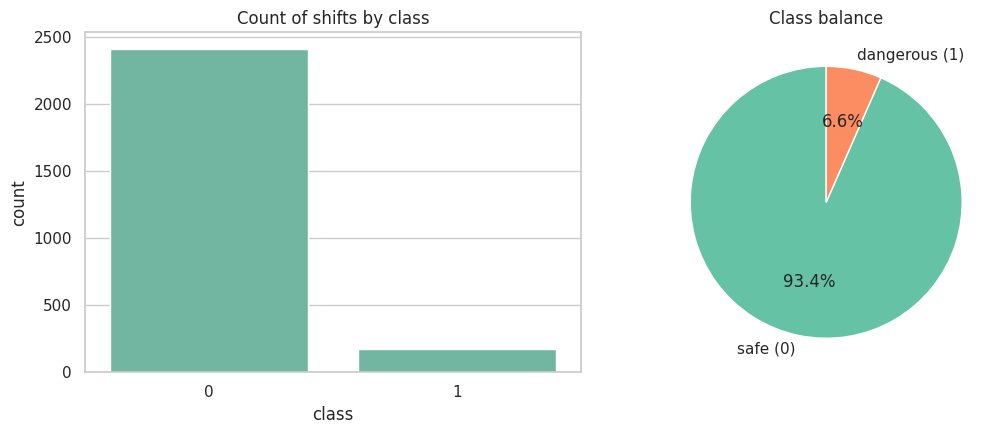

In [ ]:
class_counts = df["class"].value_counts().sort_index()
class_pct = df["class"].value_counts(normalize=True).sort_index() * 100
print(class_counts)
print(class_pct.round(2))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.countplot(x="class", data=df, ax=axes[0])
axes[0].set_title("Count of shifts by class")
axes[1].pie(class_counts, labels=["safe (0)", "dangerous (1)"], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Class balance")
plt.tight_layout(); plt.show()

normalize = True -> make all the values between 0 and 1, converets values to proportions to get the percentage.

class data is imbalanced as the safe(0) values is 93.42% of the data and the dangerous(1) values is 6.58% of the data

# 3. Descriptive statistics for numeric features

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2584 entries, 0 to 2583
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    2584 non-null   int64  
 1   seismic               2584 non-null   object 
 2   seismoacoustic        2584 non-null   object 
 3   shift                 2584 non-null   object 
 4   genergy               2584 non-null   float64
 5   gpuls                 2584 non-null   float64
 6   gdenergy              2584 non-null   int64  
 7   gdpuls                2584 non-null   int64  
 8   ghazard               2584 non-null   object 
 9   nbumps                2584 non-null   int64  
 10  nbumps2               2584 non-null   int64  
 11  nbumps3               2584 non-null   int64  
 12  nbumps4               2584 non-null   int64  
 13  nbumps5               2584 non-null   int64  
 14  nbumps6               2584 non-null   int64  
 15  nbumps7              

In [ ]:
# data before transformation
data = pd.read_csv('/content/clean_data_for_EDA _brfore transformation.csv')
num_cols = [c for c in data.select_dtypes(include='number').columns if c not in ['id', 'class']]
data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
genergy,2584.0,90242.523220,229200.508894,100.000000,11660.000000,25485.000000,52832.500000,2.595650e+06
gpuls,2584.0,538.579334,562.652536,2.000000,190.000000,379.000000,669.000000,4.518000e+03
gdenergy,2584.0,12.375774,80.319051,-96.000000,-37.000000,-6.000000,38.000000,1.245000e+03
gdpuls,2584.0,4.508901,63.166556,-96.000000,-36.000000,-6.000000,30.250000,8.380000e+02
nbumps,2584.0,0.859520,1.364616,0.000000,0.000000,0.000000,1.000000,9.000000e+00
nbumps2,2584.0,0.393576,0.783772,0.000000,0.000000,0.000000,1.000000,8.000000e+00
nbumps3,2584.0,0.392802,0.769710,0.000000,0.000000,0.000000,1.000000,7.000000e+00
nbumps4,2584.0,0.067724,0.279059,0.000000,0.000000,0.000000,0.000000,3.000000e+00
nbumps5,2584.0,0.004644,0.068001,0.000000,0.000000,0.000000,0.000000,1.000000e+00
nbumps6,2584.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00


before using `log1p` transform to handle the outliers
> ***overall:***
*data has a strong positive skewness, rare extreme events, and substantial redundancy among some variables.*

*   **genergy:** `mean 90,242`, `median 25,485` the mean is over 3 times the median -> right skew, huge diffrence between the 75th percentile and the maximum, maximum is about 49 times larger than the 75th percentile -> small number of values caused this right skew

*   **gplus:** `mean 538.6`, `median 379` same as **genergy** right skew and a huge diffrence between the 75th percentile and the maximum

*   **gdenergy and gdpuls:**
A negative value indicates that the current reading is below its recent reference level, while a positive value indicates that it is above that level. the median is negative but the positive extreme values increased the means.

*   **nbumps : nbumps5 ->** mostly zero, Most shifts have no bumps and higher energy bump categories occur much less frequently speacially nbumps5 is extremely rare


*   **nbumps6, nbumps7 and nbumps89:** all values are zero, so they provide no information and can be dropped.

*   **energy and maxenergy:** extremely right-skewed. Their median is 0, while their maximum values are extremely large, indicating that most shifts have low energy but a few shifts contain very large seismic events.

*   **has_any_bump:** it does has the values of 0/1 so `mean 0.433` indicates that 43.3% of shifts had at least one bumb.

*   **has_high_energy_bump:** all values are zero, Built from `nbumps89`, which is itself constant at 0. can be dropped.

*   **high_energy_bumps:** `mean 0.072`, `median 0`, `max 3` rare even among shifts that do have bumps.

*   **low_energy_bumps:** `mean 0.786`, higher than `high_energy_bumps`

*   **high_energy_ratio:** median and the 75the percentile are 0, and  `maximum 0.667`. This indicates that the distribution is concentrated at zero

*   **avg_energy_per_bump:** `mean 1,586`, while the `median 0`.
The zero median is due to shifts without any bumps.

*   **energy_per_pulse:** `min 7.16`, `median 70.3`, `max 996.8`, no zeros at all. as it's driven from energy and recorded pulse count. Its positive values are consistent with both source variables being nonzero.

*   **both_positive_dev and both_negative_dev:** about 80% of observations have deviations in the same direction, 35.3% positive and 44.7% negative.
*   **dev_magnitude:** `mean 71.6` is higher than the `median 54.1` and the large `maximum 1,500` indicate a right-skewed distribution of the engineered magnitude.
median of 54.1 describes the central observation of this magnitude measure. The maximum indicates that at least one shift has an exceptionally large combined deviation under your formula.

*   **any_high_hazard:** `mean 0.0209` only 2.1% of shifts had any source flag c (high hazard) at all -> rare condition.




















In [ ]:
num_cols = [c for c in df.select_dtypes(include='number').columns if c not in ['id', 'class']]
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
genergy,2584.0,10.221153,1.393800,4.615121,9.364005,10.145885,10.874899,14.769348
gpuls,2584.0,5.769602,1.160420,1.098612,5.252273,5.940171,6.507278,8.416046
gdenergy,2584.0,12.375774,80.319051,-96.000000,-37.000000,-6.000000,38.000000,1245.000000
gdpuls,2584.0,4.508901,63.166556,-96.000000,-36.000000,-6.000000,30.250000,838.000000
nbumps,2584.0,0.859520,1.364616,0.000000,0.000000,0.000000,1.000000,9.000000
nbumps2,2584.0,0.393576,0.783772,0.000000,0.000000,0.000000,1.000000,8.000000
nbumps3,2584.0,0.392802,0.769710,0.000000,0.000000,0.000000,1.000000,7.000000
nbumps4,2584.0,0.067724,0.279059,0.000000,0.000000,0.000000,0.000000,3.000000
nbumps5,2584.0,0.004644,0.068001,0.000000,0.000000,0.000000,0.000000,1.000000
nbumps6,2584.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


after using `log1p` transform to handle the outliers
> ***overall:***
*the strong right-skew in most of these columns is now much less extreme, mean and median are close together for almost every transformed column. Columns not touched by the transform keep exactly the same shape as before.*

*   **genergy:** `mean 10.22`, `median 10.15` the mean and median are now almost equal -> the transform pulled the distribution close to symmetric, a big change from the raw version where the mean was over 3 times the median. `75th percentile 10.87` vs `maximum 14.77` is now only about 1.4 times apart, not 49 times -> the extreme right tail is gone.

*   **gpuls:** `mean 5.77`, `median 5.94` the mean is now slightly *below* the median -> the skew didn't just shrink, it flipped the direction, meaning the compression overcorrected a little rather than landing exactly at symmetric. `75th percentile 6.51` vs `maximum 8.42` is a small gap, same as genergy.

*   **gdenergy and gdpuls:** unchanged, since these were not log-transformed (they contain negative values, and `log1p` needs values greater than -1).

*   **nbumps : nbumps5 ->** unchanged, not log-transformed

*   **nbumps6, nbumps7 and nbumps89:** unchanged, all values are still zero, so they still provide no information and can still be dropped.

*   **energy and maxenergy:** their median is still 0, since `log1p(0)=0` doesn't move zeros -> But the non-zero tail is now far less extreme: `75th percentile 7.86`, `maximum 12.90` for energy and `7.60`, `12.90` for maxenergy is only about 1.6-1.7 times apart, compared to over 150 times on the raw scale, indicating the few very large seismic events no longer dominate the column's range.

*   **has_any_bump:** unchanged, not touched by the transform

*   **has_high_energy_bump:** unchanged, all values are still zero, still Built from `nbumps89`, which is itself constant at 0. can still be dropped.

*   **high_energy_bumps:** unchanged, not log-transformed.

*   **low_energy_bumps:** unchanged, not log-transformed.

*   **high_energy_ratio:** unchanged, not log-transformed.

*   **avg_energy_per_bump:** `mean 3.05`, `median 0`, `max 11.92`. The zero median is still due to shifts without any bumps, but the mean dropped sharply from 1,586 on the raw scale to 3.05 here, and the maximum dropped from 150,000 to 11.92

*   **energy_per_pulse:** `min 2.10`, `median 4.27`, `max 6.91`, still no zeros at all, same as before. Its range is now much narrower than before, constant with both source variables being compressed by the transform.

*   **both_positive_dev and both_negative_dev:** unchanged, since these are built from gdenergy and gdpuls which weren't transformed.

*   **dev_magnitude:** `mean 3.96` is now very close to the `median 4.01` (mean is actually skightly below it), and the `maximum 7.31` is much smaller than before -> the right-skew that was present in the raw version (mean 71.6 well above median 54.1, max 1,500) is now almost gone, even though this feature is built from gdenergy/gdpuls, which were never transformed themselves; the compression happened one step downstream on the derived magnitude.

*   **any_high_hazard:** unchanged, not affected by the transform.

In [ ]:
df.drop(columns=['nbumps6', 'nbumps7', 'nbumps89', 'has_high_energy_bump'], inplace=True)

dropped these columnes as they provide no information - all values are zero

# 4. Univariate Analysis

# 4.1 Univariate analysis - numeric features

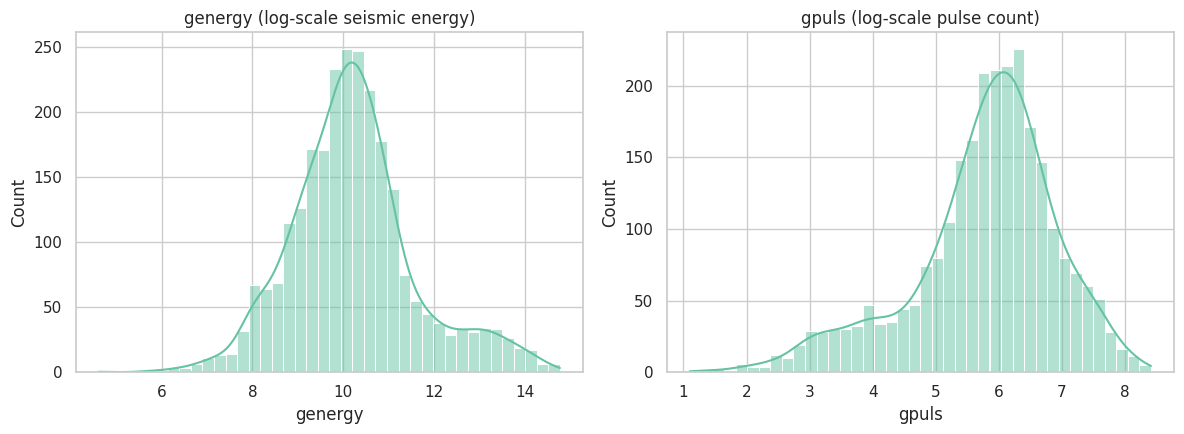

       genergy    gpuls
count  2584.00  2584.00
mean     10.22     5.77
std       1.39     1.16
min       4.62     1.10
25%       9.36     5.25
50%      10.15     5.94
75%      10.87     6.51
max      14.77     8.42


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["genergy"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("genergy (log-scale seismic energy)")
sns.histplot(df["gpuls"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("gpuls (log-scale pulse count)")
plt.tight_layout(); plt.show()
print(df[["genergy","gpuls"]].describe().round(2))

both are roughly symmetric, no negative values


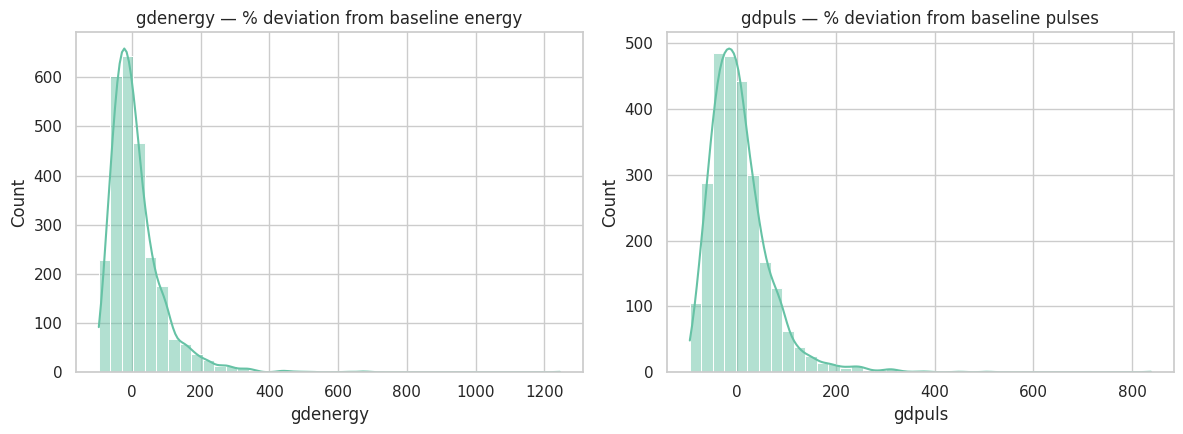

       gdenergy   gdpuls
count   2584.00  2584.00
mean      12.38     4.51
std       80.32    63.17
min      -96.00   -96.00
25%      -37.00   -36.00
50%       -6.00    -6.00
75%       38.00    30.25
max     1245.00   838.00


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["gdenergy"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("gdenergy — % deviation from baseline energy")
sns.histplot(df["gdpuls"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("gdpuls — % deviation from baseline pulses")
plt.tight_layout(); plt.show()
print(df[["gdenergy","gdpuls"]].describe().round(2))


*   both are centered at zero, data is right skew, they measures % difference from the past 8 shifts and the current value.
*   A value near 0 means current value is as usual

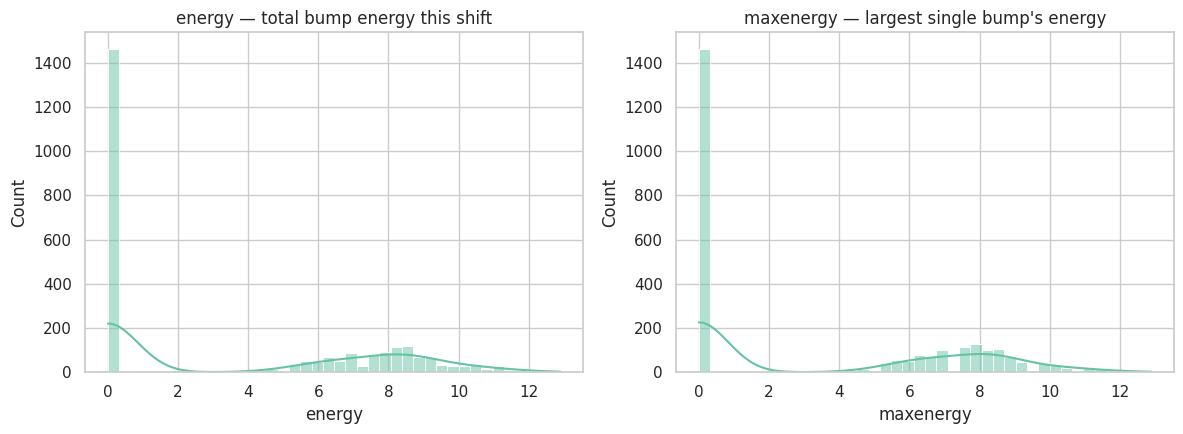

        energy  maxenergy
count  2584.00    2584.00
mean      3.48       3.40
std       4.12       4.02
min       0.00       0.00
25%       0.00       0.00
50%       0.00       0.00
75%       7.86       7.60
max      12.90      12.90
Rows with energy == 0: 1464 (56.7%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["energy"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("energy — total bump energy this shift")
sns.histplot(df["maxenergy"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("maxenergy — largest single bump's energy")
plt.tight_layout(); plt.show()

print(df[["energy","maxenergy"]].describe().round(2))
print("Rows with energy == 0:", (df["energy"]==0).sum(), f"({(df['energy']==0).mean():.1%})")

data is right skewd, 56.7% of the rows have the value 0, thats because if the nbumps sre zero there is no energy to be recoeded.

# 4.2 Univariate analysis — bump counts

count    2584.000000
mean        0.859520
std         1.364616
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         9.000000
Name: nbumps, dtype: float64
nbumps
0    1464
1     598
2     245
3     127
4      69
5      38
6      28
7       5
8       7
9       3
Name: count, dtype: int64


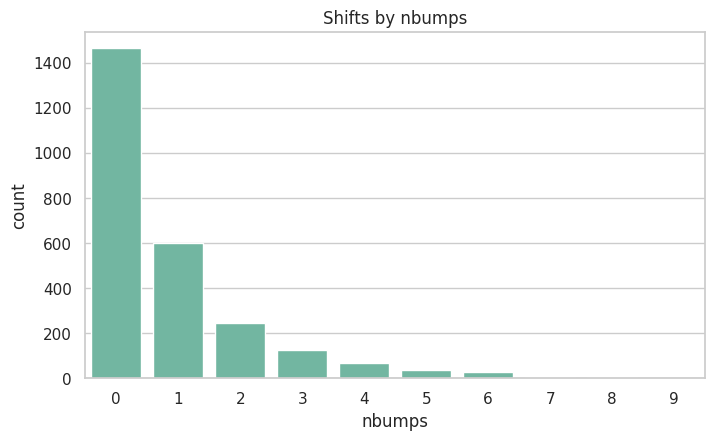

Rows with bumps == 0: 1464 (56.7%)
Rows with bumps == 1: 598 (23.1%)
Rows with bumps == 2: 245 (9.5%)
Rows with bumps == 3: 127 (4.9%)
Rows with bumps == 4: 69 (2.7%)
Rows with bumps == 5: 38 (1.5%)
Rows with bumps == 6: 28 (1.1%)
Rows with bumps == 7: 5 (0.2%)
Rows with bumps == 8: 7 (0.3%)
Rows with bumps == 9: 3 (0.1%)


In [ ]:
vc = df["nbumps"].value_counts().sort_index()
print(df["nbumps"].describe())
print(vc)

plt.figure(figsize=(8,4.5))
sns.barplot(x=vc.index, y=vc.values)
plt.title("Shifts by nbumps"); plt.xlabel("nbumps"); plt.ylabel("count")
plt.show()
for b in range(10):
    x = df["nbumps"] == b
    print(f"Rows with bumps == {b}: {x.sum()} ({x.mean():.1%})")


*   56.7% of the shifts has zero bumps, count dropped of to 23.1% for 1 bump and kept decreasing tell it reaches 9 bumbs which happend 3 times 0.1% of the shifts



# 4.3 Univariate analysis — categorical features

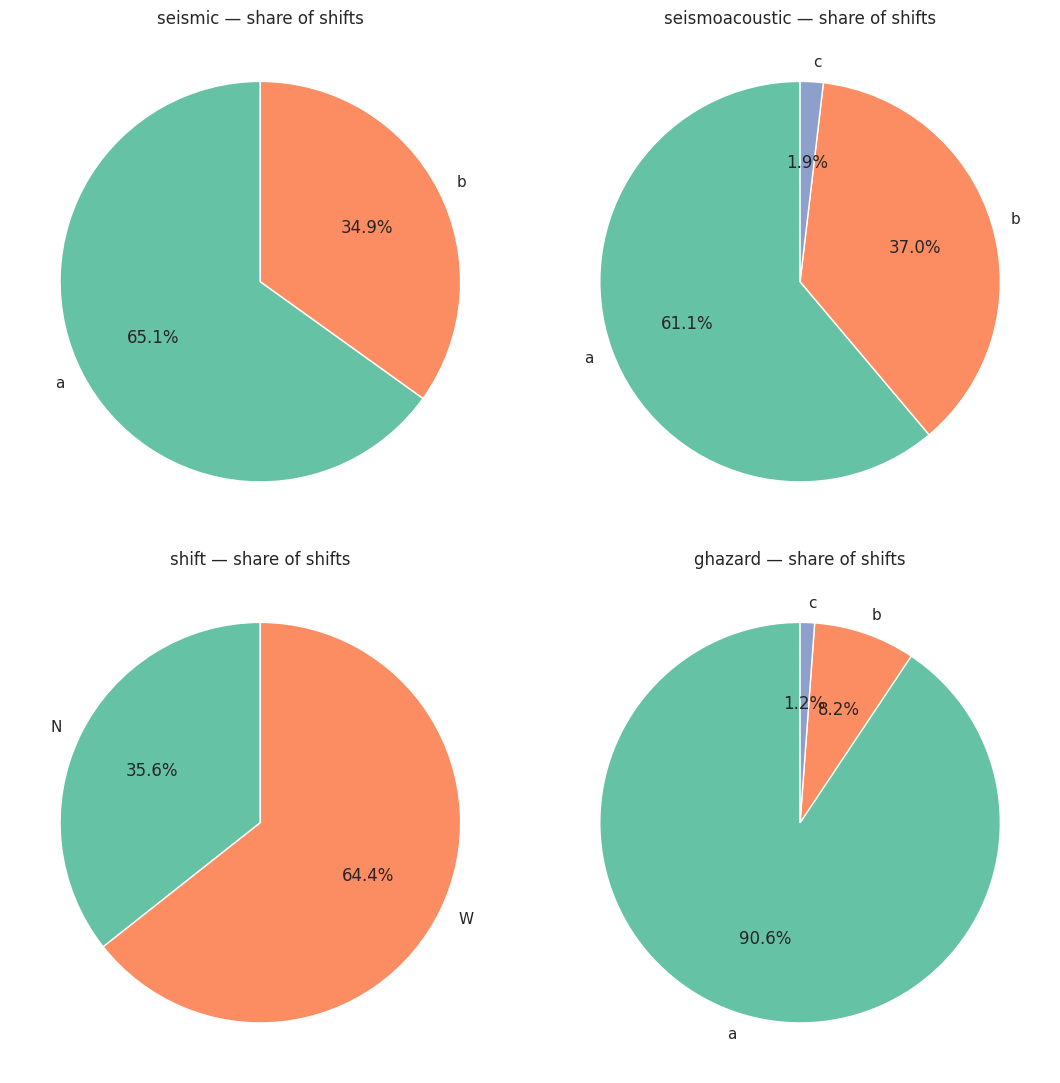

seismic {'a': 1682, 'b': 902}
seismoacoustic {'a': 1580, 'b': 956, 'c': 48}
shift {'W': 1663, 'N': 921}
ghazard {'a': 2342, 'b': 212, 'c': 30}


In [ ]:
cat_cols = ["seismic", "seismoacoustic", "shift", "ghazard"]
fig, axes = plt.subplots(2, 2, figsize=(11, 11))

for ax, c in zip(axes.ravel(), cat_cols):
    counts = df[c].value_counts().sort_index()
    ax.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90,
           colors=sns.color_palette("Set2"))
    ax.set_title(f"{c} — share of shifts")

plt.tight_layout()
plt.show()

for c in cat_cols:
    print(c, df[c].value_counts().to_dict())



*   **seismic:** about 2/3 of the shifts has a seismic method hazard of `a` while 1/3 of the shifts are `b`

*   **seismoacoustic:** a and b dominate, but c has only 48 rows (1.9% of shifts)

*   **shift:** about 2/3 of the shifts has a `W` value while the other 1/3 of the shifts has `N` value

*   **ghazard:** `a` value dominate the data as it represents 90.6% of the shifts, this is the mose unbalanced column between all the 4 columns





# 5. Bivariate Analysis

# 5.1 Bivariate analysis — numeric features vs target

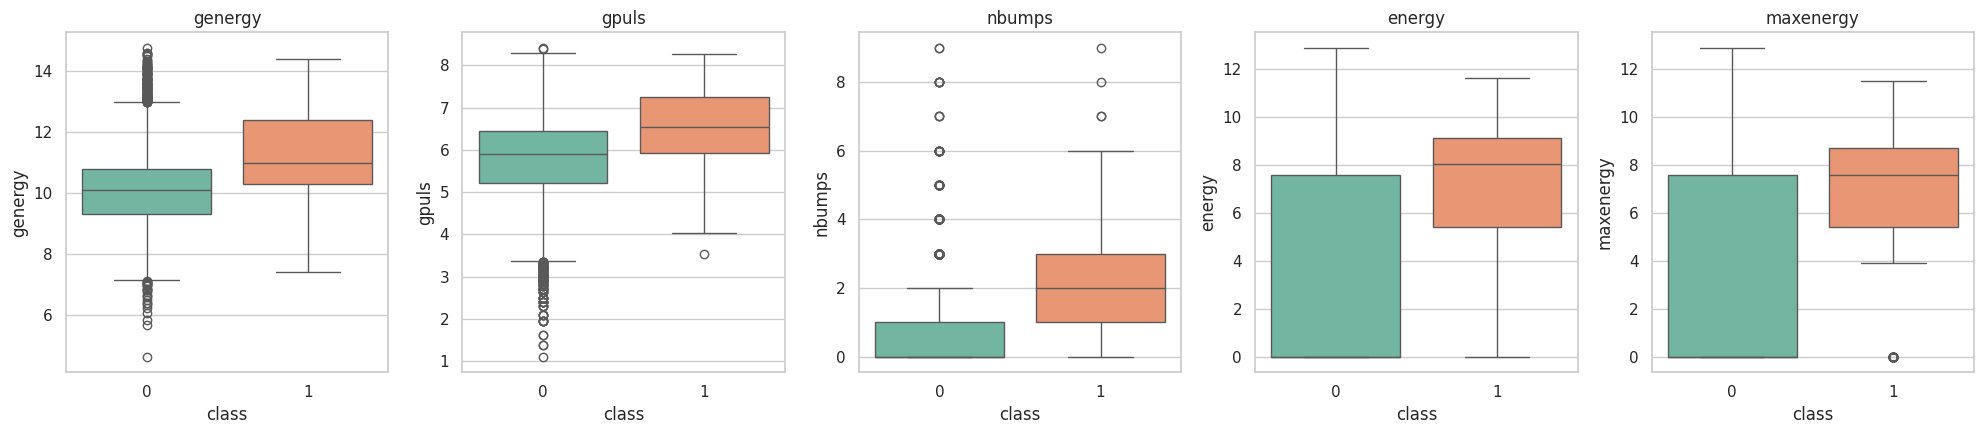

         genergy     gpuls  nbumps    energy  maxenergy
class                                                  
0      10.099917  5.899897     0.0  0.000000   0.000000
1      10.995420  6.548933     2.0  8.071219   7.601402


In [ ]:
num_feats = ["genergy", "gpuls", "nbumps", "energy", "maxenergy"]
fig, axes = plt.subplots(1, 5, figsize=(20,4.5))
for ax, c in zip(axes, num_feats):
    sns.boxplot(x="class", y=c, data=df, hue="class", legend=False, ax=ax)
    ax.set_title(c)
plt.tight_layout(); plt.show()
print(df.groupby("class")[num_feats].median())

*   **genergy and gpuls:** median is higher in the dangerous group than the safe group, with a heavy overlap between the boxes. almost normal as shown in `section 4.1`

*   **nbumbs:** higher median for dangerous shifts. as `section 4.2` showed most shifts have zero bumps, even a small upward shift in the dangerous group's median bump count is a meaningful signal.

*   **energy and maxenergy:** higher median for dangerous shifts. as showed in `section4.1` this column is zero for the majority of shifts, this result specifically says dangerous shifts are more likely to be among the minority that have any recorded bump energy at all.

> overall: the median of all 5 features is higher in the dangerous shifts (1)



# 5.2 Bivariate analysis — categorical features vs target

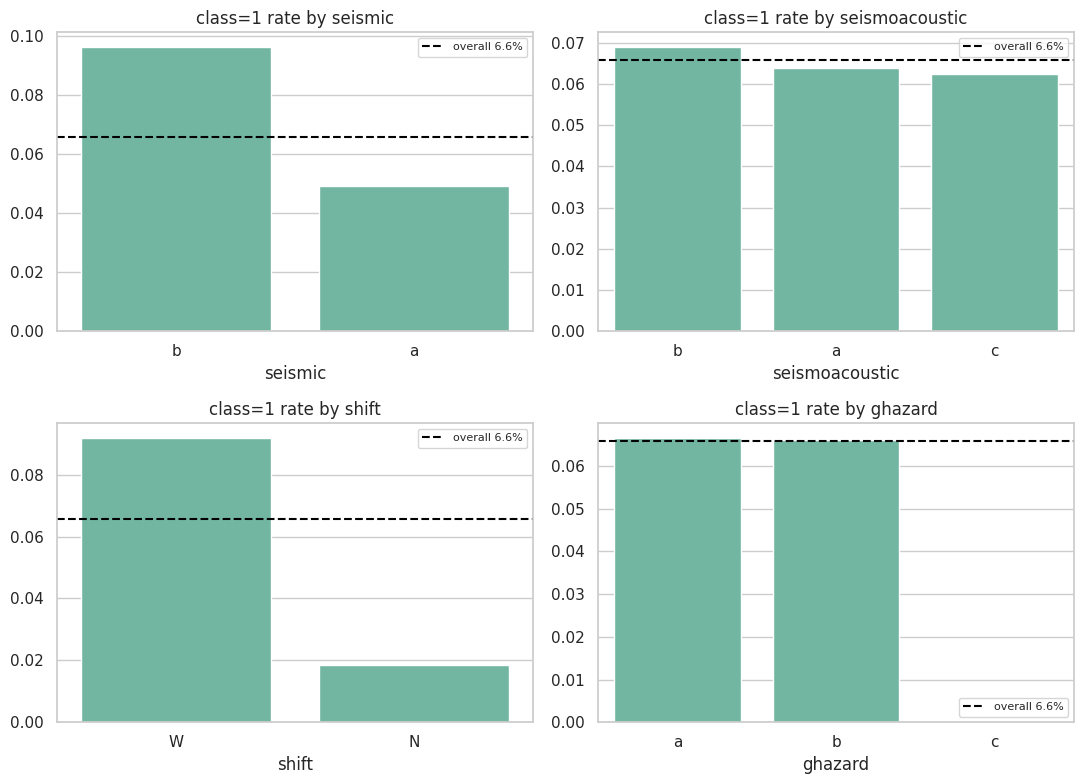

         shifts  danger_rate
seismic                     
a          1682        0.049
b           902        0.096
                shifts  danger_rate
seismoacoustic                     
a                 1580        0.064
b                  956        0.069
c                   48        0.062
       shifts  danger_rate
shift                     
N         921        0.018
W        1663        0.092
         shifts  danger_rate
ghazard                     
a          2342        0.067
b           212        0.066
c            30        0.000


In [ ]:
base_rate = df["class"].mean()
cat_cols = ["seismic", "seismoacoustic", "shift", "ghazard"]
fig, axes = plt.subplots(2, 2, figsize=(11,8))
for ax, c in zip(axes.ravel(), cat_cols):
    rates = df.groupby(c)["class"].mean().sort_values(ascending=False)
    sns.barplot(x=rates.index, y=rates.values, ax=ax)
    ax.axhline(base_rate, color="black", linestyle="--", label=f"overall {base_rate:.1%}")
    ax.set_title(f"class=1 rate by {c}"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
for c in cat_cols:
    print(df.groupby(c)["class"].agg(shifts="count", danger_rate="mean").round(3))

note: base rate is the danger rate as calculated in `section 2`

*   **seismic:** `b = 9.6%`, `a = 4.9%` b is almoust double the base rate. Both categories in `section 4.3` where 1,682 and 902 rows, are large enough, so this isn't a small-sample effect.

*   **seismoacoustic:** all rates stay close to the 6.6% base rate, no category stands out clearly above or below average.

*   **shift:** `W = 9.2%`, `N = 1.8%`, a 5 times gap, W is the largest amoung all columns. Both groups in `section 4.3` where 1,663 and 921 rows are large enough, so this isn't a small-sample effect.

*   **ghazard:** a and b almost equals ti the base rate, c shows 0%, but `section 4.3` already flagged c as it has only 30 rows, too few to treat that 0% as a real pattern rather than a sampling noise.


# 6. Multivariate analysis


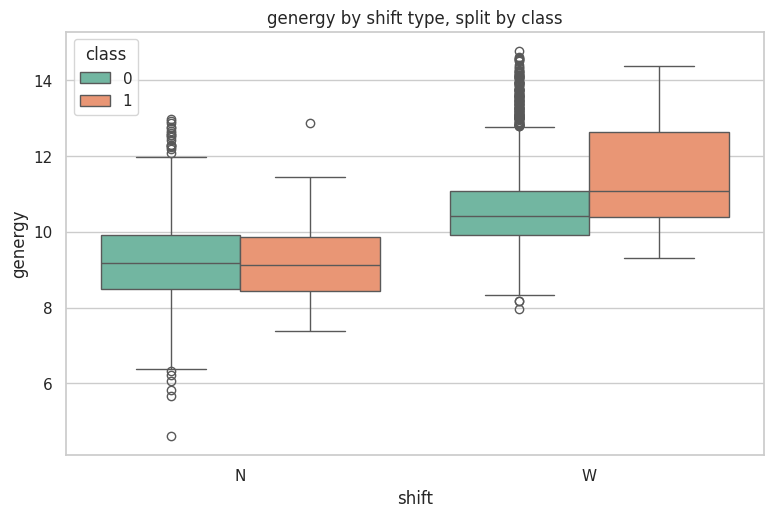

shift  class
N      0         904
       1          17
W      0        1510
       1         153
dtype: int64


In [ ]:
plt.figure(figsize=(9,5.5))
sns.boxplot(x="shift", y="genergy", hue="class", data=df)
plt.title("genergy by shift type, split by class"); plt.show()
print(df.groupby(["shift","class"]).size())



*   **N:** `class=1` shows higher genergy than `class=0` as in `section 5.1` which still the same even after splitting by shift type. But this group's dangerous subset has only 17 rows, small enough that any specific number from it deserves caution.
*   **W:** `class=1` shows higher genergy than `class=0` but it has 153 dangerous rows, a much steadier sample.




# 7. Correlation analysis

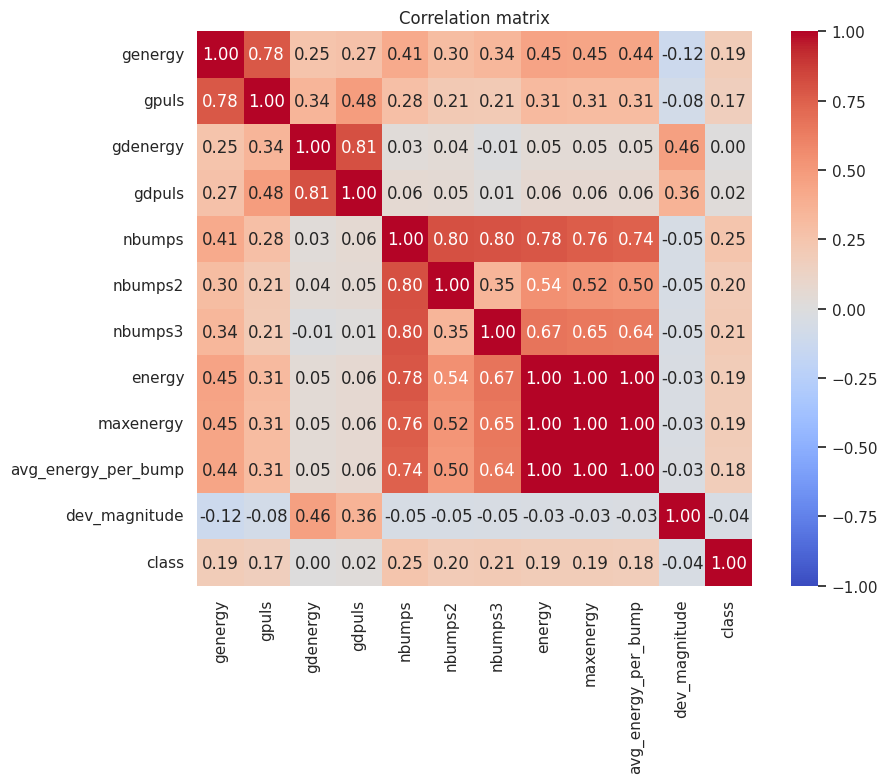

In [ ]:
corr_cols = ["genergy","gpuls","gdenergy","gdpuls","nbumps","nbumps2","nbumps3",
             "energy","maxenergy","avg_energy_per_bump","dev_magnitude","class"]
corr = df[corr_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True)
plt.title("Correlation matrix"); plt.tight_layout(); plt.show()


*   **energy, maxenergy and ave_energy_per_bump:** correlate with each other almost 1.00 perfect positive correlation confirms they're carrying almost identical information, not just independent measurements.

*   **genergy and gpuls:** correlate with each other at 0.78, a strong positive but not unnecessary relationship; more background pulses tend to come with more background energy, matching their similar shapes from `section 4.1`, but they're not simply duplicates of each other.

*   **nbumps vs class:** the strongest numeric correlation with the target at 0.25.

*   **gdenergy/gdpuls vs class**: correlation 0.00/0.02 almost no correlation. as`section 4.1` already showed both columns have a long right tail, indecates non-normal data which uses sperman as a correlation method not person which is used in the case of normality.


In [ ]:
df[['gdenergy', 'gdpuls', 'class']].corr(method='spearman')

,gdenergy,gdpuls,class
gdenergy,1.000000,0.799502,0.018705
gdpuls,0.799502,1.000000,0.035298
class,0.018705,0.035298,1.000000


the correlation results in both gdenergy and gdpuls are slightly higher after using spearman as a correlation method but still close to zero

# 8. Outlier analysis

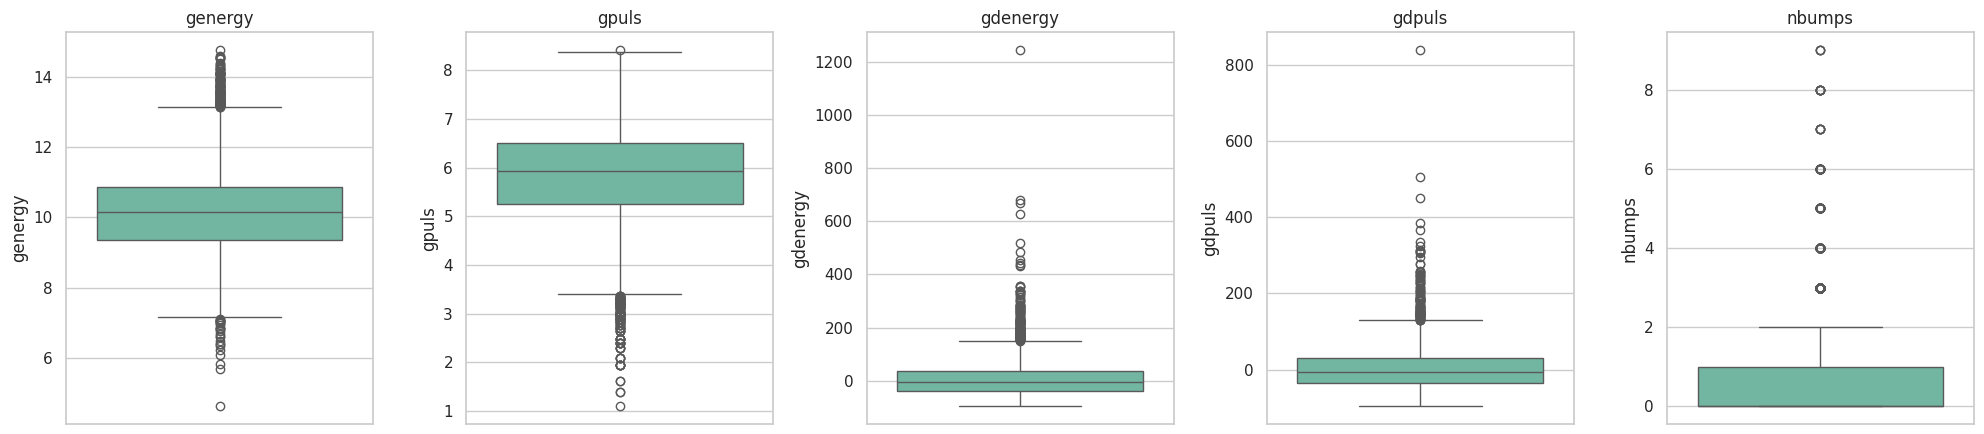

genergy   :  146 outliers (5.7%) | class=1 rate outliers: 17.8% | normal_shifts: 5.9%
gpuls     :  133 outliers (5.1%) | class=1 rate outliers: 0.0% | normal_shifts: 6.9%
gdenergy  :  141 outliers (5.5%) | class=1 rate outliers: 5.0% | normal_shifts: 6.7%
gdpuls    :   95 outliers (3.7%) | class=1 rate outliers: 6.3% | normal_shifts: 6.6%
nbumps    :  277 outliers (10.7%) | class=1 rate outliers: 22.4% | normal_shifts: 4.7%


In [ ]:
def iqr_outlier_mask(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return (s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)

cols = ["genergy","gpuls","gdenergy","gdpuls","nbumps"]
fig, axes = plt.subplots(1, 5, figsize=(20,4.5))
for ax, c in zip(axes, cols):
    sns.boxplot(y=df[c], ax=ax)
    ax.set_title(c)
plt.tight_layout(); plt.show()

for c in cols:
    mask = iqr_outlier_mask(df[c])
    print(f"{c:10s}: {mask.sum():4d} outliers ({mask.mean():.1%}) | "
          f"class=1 rate outliers: {df.loc[mask,'class'].mean():.1%} | "
          f"normal_shifts: {df.loc[~mask,'class'].mean():.1%}")


*   **genergy:** outliers were dangerous by 17.8% of the time, 5.9% for normal shifts, there is a real large gap. An unusually high genergy reading really is a warning sign here.

*   **gpuls:** outliers were dangerous by 0.0% of the time, 6.9% for normal shifts. An unusually high/low gpuls reading was not a danger sign.

*   **gdenergy:** outliers were dangerous by 5.0% of the time, 6.7% for normal shifts, no meaningful difference.

*   **gdpuls:** outliers were dangerous by 6.3% of the time, 6.6% normal,  essentially identical, no signal.

*   **nbumps:** outliers were dangerous by 22.4% of the time, 4.7% for normal shifts, this is the strongest gap of the five. An unusually high bump count is the clearest outlier-to-danger link in the dataset.

# 9. Final insght



1.   **Target is imbalanced**: 93.4% safe and 6.6% dangerous `section 2`. Accuracy is a misleading metric here since predicting "safe" every time scores more than 93%

2.   **Numeric sensor features point the same direction but weak:** `section 5.1` dangerous shifts have higher median genergy, gpuls, nbumps, energy, and maxenergy, but with heavy overlap between the safe and dangerous boxplots.

3.   **shift is the strongest single predictor:** `section 5.2` production shifts (W) are 9.2% dangerous vs 1.8% for preparation (N), a 5x gap, where column have 1,663 and 921 rows are large enough, so this isn't a small-sample effect.

4. **High feature multicollinearity::** `section 7` energy, maxenergy, and avg_energy_per_bump correlate almost 1.00 with each other, genergy/gpuls correlate 0.78. A linear model doesn't need all of these at once.

5.   **Weak Features:** `section 7` gdenergy and gdpuls show almost no relationship with the target, linear or ranked, both Pearson and Spearman correlations stay close to zero. Combined with the outlier finding `section 8`, these two look like the weakest predictors in the dataset.

6.   **Outliers does matter for two features:** `section 8` genergy and nbumps outliers are meaningfully more dangerous than normal readings 17.8% and 22.4% while normal are 5.9% and 4.7%. gpuls outliers were actually safer 0.0% and 6.9% for normal, and gdenergy and gdpuls outliers showed no difference at all.

7.   **Model Recommendation** for the classification use a `Logistic Regression` as the baseline and `Random Forest` as the main model as it can combine the week features `insight 2` without needing to scale them and some outliers does matter `insight 6`.


